In [1]:
import os
import shutil
import pathlib
from typing import Sequence

from tensorflow.python.keras import Sequential
from tensorflow.python.layers.pooling import MaxPooling2D
#0. 작업 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#데이터 분할
from sklearn.model_selection import train_test_split
#모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Dropout,SimpleRNN,LSTM,GRU,BatchNormalization,Flatten
from keras.optimizers import Adam,RMSprop,SGD,Adagrad
from keras.losses import binary_crossentropy,categorical_crossentropy,sparse_categorical_crossentropy,mean_squared_error
#모델 학습
from keras.callbacks import EarlyStopping,ModelCheckpoint
#모델 로드
from keras.models import load_model
#성능검토
from sklearn.metrics import r2_score,classification_report,f1_score,mean_squared_error
from tensorflow import truediv

In [2]:
old_dir = pathlib.Path('dogs-vs-cats/train')

In [9]:
old_dir

PosixPath('dogs-vs-cats/train')

In [10]:
new_dir = pathlib.Path('dogs-vs-cats_data_split')

In [3]:
def make_subset(sub_n, s_idx, e_idx):
    for i in ['cat', 'dog']:
        dir = new_dir/sub_n/i
        os.makedirs(dir)
        f_ns = [ f'{i}.{n}.jpg' for n in range(s_idx, e_idx)]
        for f_n in f_ns:
            shutil.copyfile(src=old_dir/f_n, dst=dir/f_n)

In [12]:
make_subset('tr_data', 0, 1000)

In [13]:
make_subset('tt_data', 1000, 2000)

In [14]:
from keras.utils import image_dataset_from_directory
tr_ds=image_dataset_from_directory(new_dir/'tr_data',batch_size=32,image_size=(180,180))
tt_ds=image_dataset_from_directory(new_dir/'tt_data',batch_size=32,image_size=(180,180))

Found 2000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [15]:
tr_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
m = Sequential()
m.add(Input(shape=(180, 180, 3)))
m.add(Conv2D(32, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(100, activation='relu'))
m.add(Dense(1, activation='sigmoid'))

# m.summary()
m.compile(loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(tr_ds, epochs=100)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - acc: 0.4805 - loss: 1430.6497
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.5358 - loss: 173.2828
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.5295 - loss: 546.4233
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.5232 - loss: 320.3922
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.5419 - loss: 282.0884
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.5575 - loss: 225.8250
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.5591 - loss: 185.0228
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.6239 - loss: 112.8035
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.6392 - loss: 139.5915
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.6774 - loss: 87.7026
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.6021 - loss: 220.7115
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.6351 - loss: 154.6579
E

In [ ]:
# scale: Any,
# offset: float = 0.0,
# **kwargs: Any

In [ ]:
# 데이터 변환 계층
from keras.layers import Rescaling, RandomZoom, RandomRotation, RandomFlip # 데이터 증강 계층

In [ ]:
m = Sequential()
m.add(Input(shape=(180, 180, 3)))
m.add(Rescaling(scale=1./255)) # Rescaling(scale=1./127.5, offset = -1) -> -1~1 로 범주 정의
m.add(Conv2D(32, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(100, activation='relu'))
m.add(Dense(1, activation='sigmoid'))

# m.summary()
m.compile(loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(tr_ds, epochs=100)

Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - acc: 0.5335 - loss: 2.7710
Epoch 2/3
27/63 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - acc: 0.6327 - loss: 0.6520

KeyboardInterrupt: 

In [ ]:
hy = m.fit(tr_ds, epochs=3)

Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 323ms/step - acc: 0.5625 - loss: 0.7087
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 347ms/step - acc: 0.6405 - loss: 0.6489
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 363ms/step - acc: 0.6710 - loss: 0.6036


(32, 180, 180, 3)


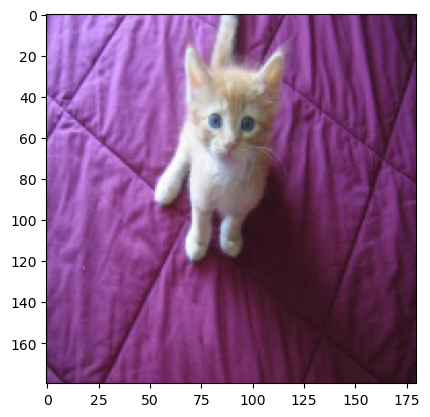

In [ ]:
for imgs,ys in tr_ds.take(1):
    print(imgs.shape)
    plt.imshow(imgs[0].numpy().astype('uint8'))
    plt.show()
    break

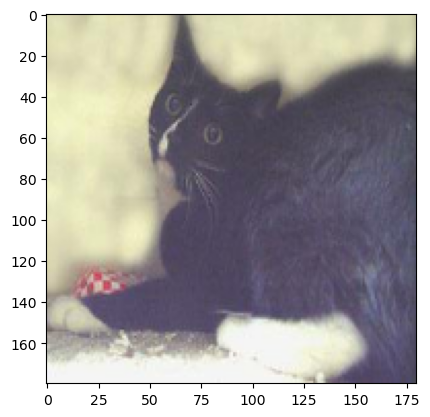

In [ ]:
# 데이터 증강 확인
# (텐서, 라벨)
for imgs,ys in tr_ds:
    plt.imshow(imgs[0].numpy().astype('uint8'))
    plt.show()
    break

In [ ]:
# 데이터 변환 계층
from keras.layers import Rescaling, RandomZoom, RandomRotation, RandomFlip # 데이터 증강 계층

In [ ]:
# 데이터가 변환 되는 것은 아니다
data_add_m = Sequential()
data_add_m.add(RandomZoom(0.2))
data_add_m.add(RandomRotation(0.1))
for imgs, ys in tr_ds:
    for k in range(9):
        data1 = data_add_m(imgs)
        ax = plt.subplot(3, 3, k+1)
        plt.imshow(data1[k].numpy().astype('uint8'))
        plt.axis('off')
    plt.show()
    break

# **로드한 데이터 셋을 이용하여 최적의 모델을 설계후 학습된 모델을 완성하시오**
1. 우리가 형성한 데이터셋 함수를 이용하여 데이터를 늘리시오(최대 5000장)
2. 학습,테스트, 검증 데이터셋을 구성하여 사용하시오
3. 데이터 스케일링은 계층을 이용하시오
4. 데이터 증강 계층을 사용하시오
    - 1번 모델은 사용안함
    - 2번 모델은 사용함
    - 단 데이터는 변경 되면 안됨

In [ ]:
!cd

C:\Users\user\Desktop\data\DL


In [13]:
new_dir = pathlib.Path('dogs-vs-cats_data')

In [4]:
# 1번
new_dir = pathlib.Path('dogs-vs-cats_data_split')
make_subset('tr_data', 0, 5000)
make_subset('tt_data', 5000, 10000)

In [5]:
# 2번
from keras.utils import image_dataset_from_directory
tr_ds = image_dataset_from_directory(
    new_dir/'tr_data',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)
val_ds = image_dataset_from_directory(
    new_dir/'tr_data',
    validation_split=0.2,   # train과 동일한 split 값
    subset="validation",    # → "나머지 20%" 부분을 val_ds 로 가져옴
    seed=123,               # seed 동일해야 train/val 이 겹치지 않음
    image_size=(180, 180),
    batch_size=32
)

tt_ds=image_dataset_from_directory(
    new_dir/'tt_data',
    batch_size=32,
    image_size=(180,180)
)

Found 10000 files belonging to 2 classes.
Using 8000 files for training.
Found 10000 files belonging to 2 classes.
Using 2000 files for validation.
Found 10000 files belonging to 2 classes.


In [6]:
tr_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [7]:
# 데이터 변환 계층
from keras.layers import Activation
from keras.layers import Rescaling, RandomZoom, RandomRotation, RandomFlip # 데이터 증강 계층

In [8]:
# 4번 증강 사용안함
m = Sequential()
m.add(Input(shape=(180, 180, 3)))
m.add(Rescaling(scale=1./255))
m.add(Conv2D(32, 3, 1, padding='same'))
m.add(BatchNormalization())
m.add(Activation("relu"))
m.add(Conv2D(32, 3, 1, padding='same'))
m.add(BatchNormalization())
m.add(Activation("relu"))
m.add(MaxPooling2D(2))
m.add(Conv2D(64, 3, 1, padding='same'))
m.add(BatchNormalization())
m.add(Activation("relu"))
m.add(MaxPooling2D(2))
m.add(Conv2D(128, 3, 1, padding='same'))
m.add(BatchNormalization())
m.add(Activation("relu"))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(100, activation='relu'))
m.add(Dense(1, activation='sigmoid'))

# m.summary()
m.compile(optimizer=Adam(learning_rate=0.0002),
          loss='binary_crossentropy', 
          metrics=['acc'])

es = EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
ck = ModelCheckpoint('best_m.keras', save_best_only=True, verbose=1)

hy = m.fit(tr_ds,validation_data=(val_ds), epochs=50, callbacks=[es,ck], batch_size=64)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - acc: 0.6062 - loss: 1.8288
Epoch 1: val_loss improved from inf to 0.87930, saving model to best_m.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 114ms/step - acc: 0.6063 - loss: 1.8263 - val_acc: 0.5345 - val_loss: 0.8793
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - acc: 0.7255 - loss: 0.6262
Epoch 2: val_loss improved from 0.87930 to 0.85291, saving model to best_m.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - acc: 0.7254 - loss: 0.6263 - val_acc: 0.6450 - val_loss: 0.8529
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - acc: 0.7632 - loss: 0.5275
Epoch 3: val_loss improved from 0.85291 to 0.75511, saving model to best_m.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - acc: 0.7631 - loss: 0.5276 - val_acc: 0.6835 - val_loss: 0.7551
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - acc: 0.8069 - loss: 0.4360
Epoch 4: val_loss improved from 0.75511 to 0.69860, saving model to best_m.keras
250/250 ━━━━━━━━━━

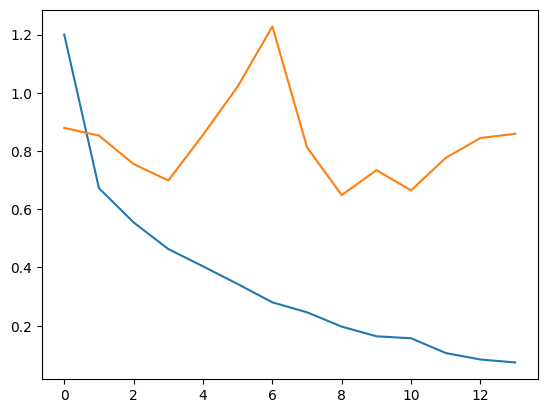

In [9]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])

In [ ]:
data_augmentation = Sequential([
    RandomRotation(0.1),
    RandomZoom(0.2),
])

m = Sequential()
m.add(RandomRotation(0.1)),
m.add(RandomZoom(0.2)),
m.add(Input(shape=(180, 180, 3)))
m.add(Rescaling(scale=1./255))
m.add(Conv2D(32, 3, 1, padding='same'))
m.add(BatchNormalization())
m.add(Activation("relu"))
m.add(Conv2D(32, 3, 1, padding='same'))
m.add(BatchNormalization())
m.add(Activation("relu"))
m.add(MaxPooling2D(2))
m.add(Conv2D(64, 3, 1, padding='same'))
m.add(BatchNormalization())
m.add(Activation("relu"))
m.add(MaxPooling2D(2))
m.add(Conv2D(128, 3, 1, padding='same'))
m.add(BatchNormalization())
m.add(Activation("relu"))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(100, activation='relu'))
m.add(Dense(1, activation='sigmoid'))

m.summary()
m.compile(optimizer=Adam(learning_rate=0.0005),
          loss='binary_crossentropy', 
          metrics=['acc'])

es = EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
ck = ModelCheckpoint('best_m.keras', save_best_only=True, verbose=1)

hy = m.fit(tr_ds,validation_data=(val_ds), epochs=50, callbacks=[es,ck])

In [10]:
# 모델 평가
best_m = load_model('best_m.keras')


# 예측 및 결과 확인
tr_scs_m = best_m.evaluate(tr_ds)
val_scs_m = best_m.evaluate(val_ds)
tt_scs_m = best_m.evaluate(tt_ds)

all_acc_m=abs(tr_scs_m[1]-val_scs_m[1])+abs(tr_scs_m[1]-tt_scs_m[1])+abs(tt_scs_m[1]-val_scs_m[1])
print(f'all_acc_m : {all_acc_m}')

all_loss_m=abs(tr_scs_m[0]-val_scs_m[0])+abs(tr_scs_m[0]-tt_scs_m[0])+abs(tt_scs_m[0]-val_scs_m[0])
print(f'all_loss_m : {all_loss_m}')

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - acc: 0.9344 - loss: 0.1741
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.7492 - loss: 0.6348
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - acc: 0.7535 - loss: 0.6373
all_acc_m : 0.3710000514984131
all_loss_m : 0.9738403558731079
